# 03 Real Crop Dataset Analysis

This notebook audits the real-world UK plate crop dataset used for custom CNN fine-tuning.

It is intentionally portfolio-facing: it shows the data engineering work behind the recogniser, not just the final model. The dataset was built from collected vehicle/plate imagery, cropped into plate regions, cleaned into the fixed UK `LLNNLLL` format, and checked before train/validation/test splitting.

The report focuses on:

- dataset size and valid filename labels
- duplicate labels and duplicate image hashes
- plate character distribution by position
- crop dimensions, aspect ratios, and suspicious crop candidates
- grouped split readiness to avoid plate-label leakage
- saved CSV/JSON report artifacts for later training steps


## How To Read This Notebook

The code cell below is a self-contained report generator. Its output is kept in the notebook so reviewers can see the analysis without rerunning it. If the dataset changes, rerun the code cell from the `uk_plate_recognition` project root to refresh the tables, plots, and generated report files under `outputs/real_crop_dataset_report/`.


# UK ANPR Real Crop Dataset Report

**Dataset folder:** `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_LLNNLLL_2`  
**Generated:** `2026-06-03 20:49:09`  
**Expected filename format:** `LLNNLLL`, for example `AB12CDE.jpg` or `AB12CDE_002.jpg`

This report checks whether the cleaned real-world crop dataset is ready for grouped train/validation/test splitting and later CNN fine-tuning.

## Dataset Provenance

This dataset is part of the project data pipeline: full vehicle/plate imagery was collected, plate regions were cropped, filenames were normalised into the fixed UK `LLNNLLL` format, and metadata/report artifacts were generated for training decisions. The filename prefix is treated as the label, so invalid filenames and duplicate groups are explicitly checked before model training.

### Dataset Summary

,metric,value
0,Total files in folder,"12,238"
1,Image files,"12,238"
2,Non-image files,0
3,Valid LLNNLLL filename images,"12,238"
4,Invalid filename images,0
5,Unique plate labels,"11,171"
6,Labels with exactly 1 image,"10,445"
7,Labels with 2+ images,726
8,Duplicate image hashes,0
9,Suspicious crops,0


✅ **Filename check passed:** every image filename starts with valid `LLNNLLL`.

### Invalid Filename Examples

...

""


✅ **Duplicate hash check passed:** no byte-identical duplicate image files found.

## Grouped Train/Validation/Test Split Readiness

For this dataset, a grouped split means:

- group key = `label`
- all images of the same plate stay in the same split
- prevents data leakage
- gives a more honest validation/test result

### Grouped Split Readiness

,metric,value
0,Unique labels available for grouped split,"11,171"
1,Estimated train labels at 80%,"8,936"
2,Estimated validation labels at 10%,"1,117"
3,Estimated test labels at 10%,"1,118"
4,Readiness judgement,✅ Strong dataset size for a portfolio fine-tun...


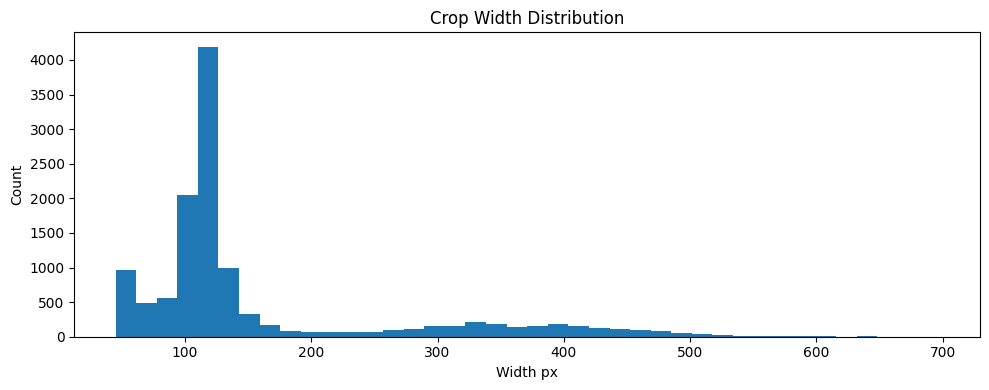

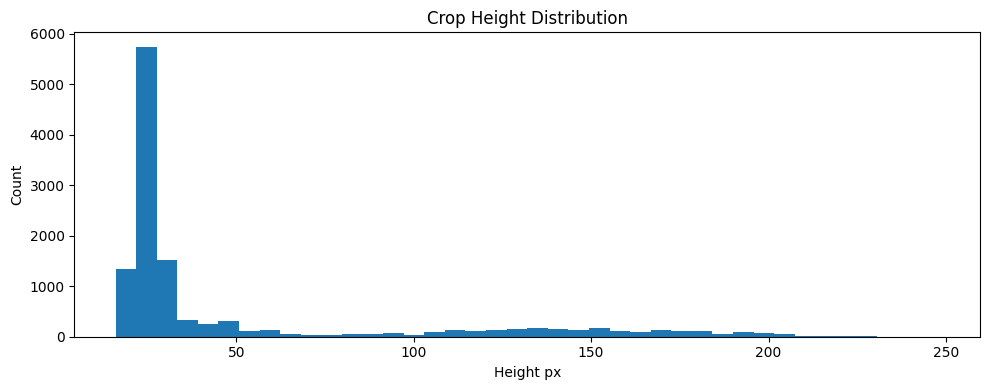

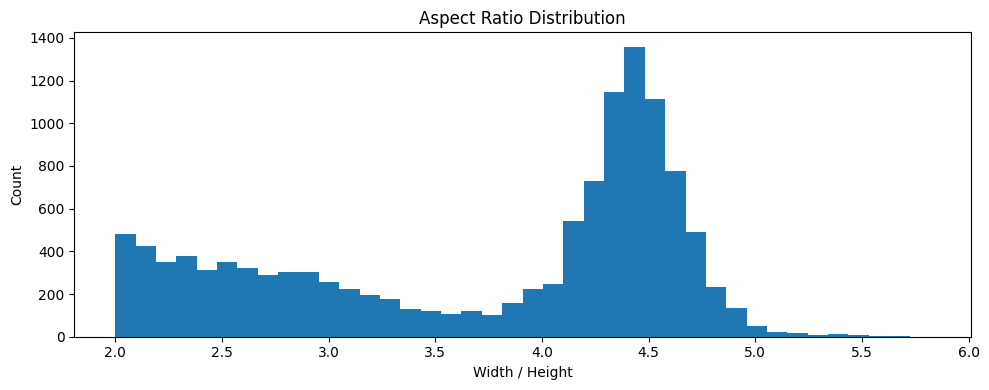

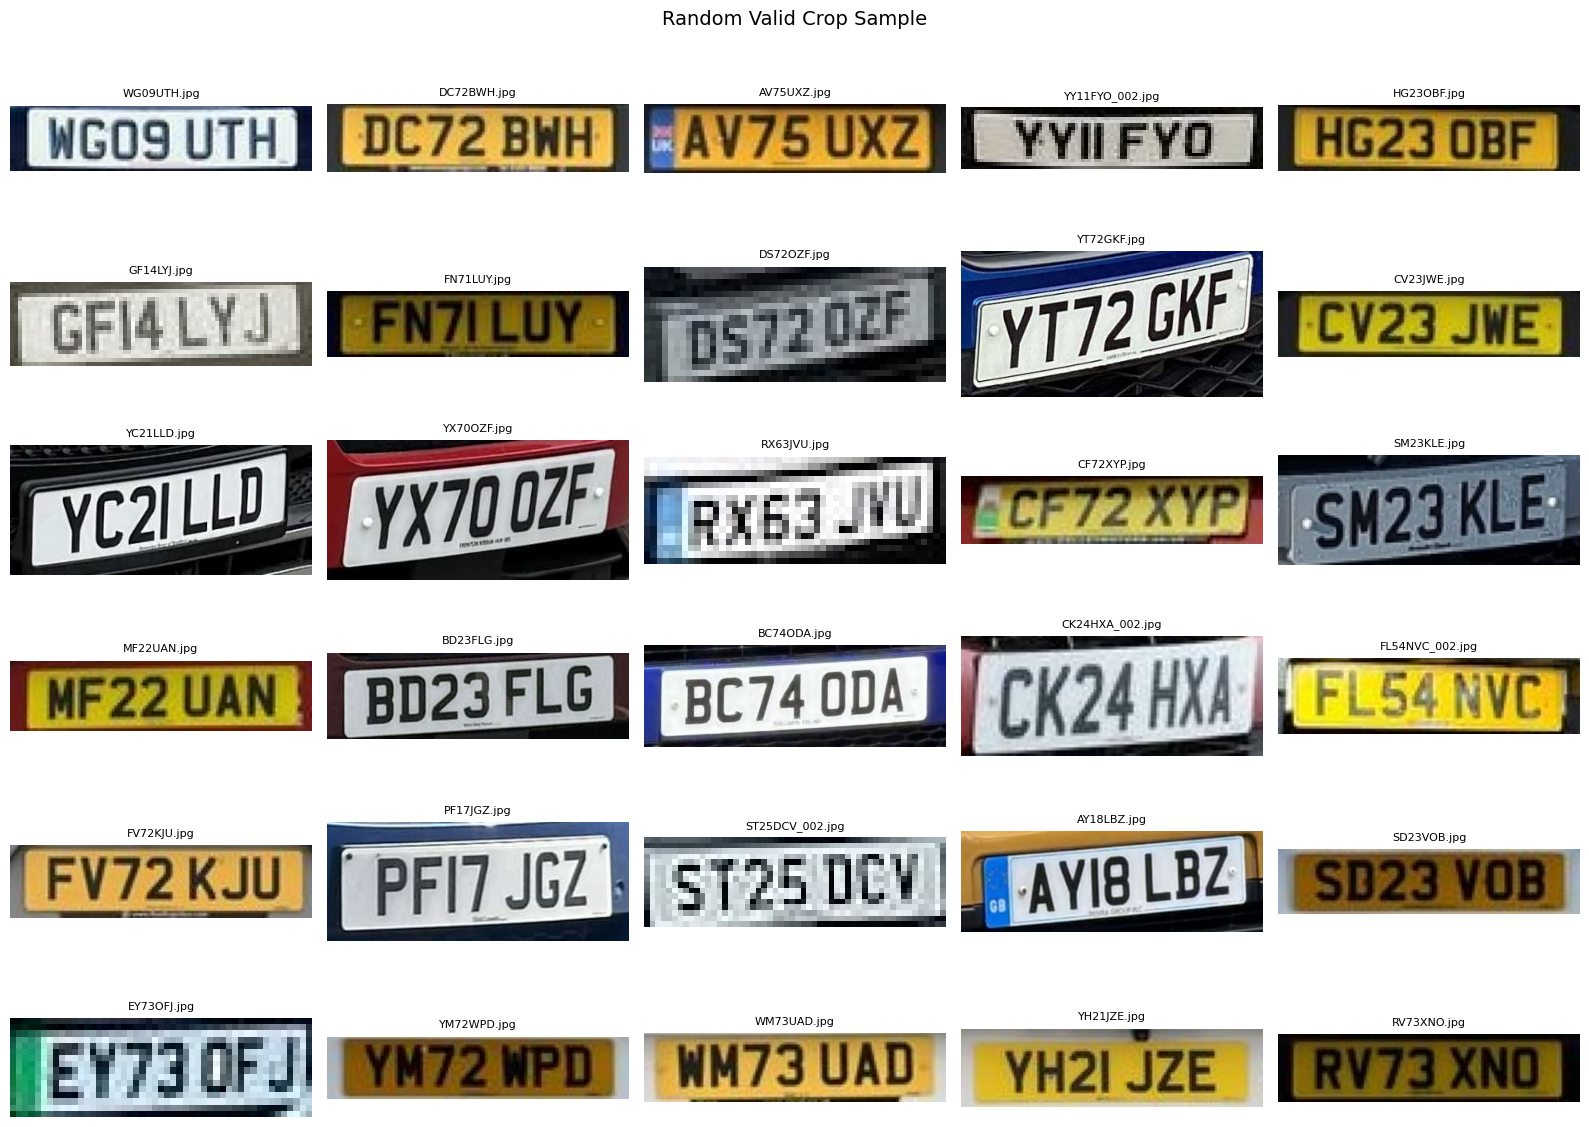

### Suspicious Crop Sample

No images to display.

## Saved Report Files

The notebook saved these files:

- `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\plate_crops_LLNNLLL_analysis_rows.csv`
- `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\plate_crops_LLNNLLL_summary.json`
- `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\plate_crops_LLNNLLL_suspicious.csv`
- `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\plate_crops_LLNNLLL_duplicate_hashes.csv`
- `C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\real_crop_dataset_report\plate_crops_LLNNLLL_current_style_rule_violations.csv`

In [2]:

# ============================================================
# UK ANPR REAL CROP DATASET ANALYSIS REPORT
# Target folder: data/raw/plate_crops_LLNNLLL_2/
#
# Run this notebook from the uk_plate_recognition project root.
# The report is self-contained so it can be rerun after dataset updates.
# ============================================================
import json
from pathlib import Path
from collections import Counter
from datetime import datetime
import hashlib
import math
import random
import re
import statistics
import textwrap

# Optional notebook/report dependencies.
# The script keeps working even if some are unavailable.
try:
    import pandas as pd
except Exception:
    pd = None

try:
    import numpy as np
except Exception:
    np = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from PIL import Image
except Exception:
    Image = None

try:
    from IPython.display import display, Markdown
except Exception:
    display = None
    Markdown = None


# ----------------------------
# 1. CONFIG
# ----------------------------
TARGET_RELATIVE_DIR = Path("data/raw/plate_crops_LLNNLLL_2")
VALID_PLATE_RE = re.compile(r"^[A-Z]{2}[0-9]{2}[A-Z]{3}$")
VALID_PREFIX_RE = re.compile(r"^([A-Z]{2}[0-9]{2}[A-Z]{3})")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DVLA_INF104_URL = "https://www.gov.uk/government/publications/vehicle-registration-numbers-and-number-plates"

# Current-style UK registration rules used by this LLNNLLL dataset.
# Source: DVLA INF104. These checks intentionally do not cover NI, Q, private, or historic formats.
LOCAL_MEMORY_TAG_EXCLUDED_CHARS = {"I", "Q", "Z"}
RANDOM_SUFFIX_EXCLUDED_CHARS = {"I", "Q"}
VALID_LOCAL_MEMORY_TAGS = set()
VALID_LOCAL_MEMORY_TAGS.update("A" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
# VALID_LOCAL_MEMORY_TAGS.update(ch1 + ch2 for ch2 in "ABCDEFGHJKLMNOPRSTUVWXY" for ch1 in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("B" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("C" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("D" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("E" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("F" + ch for ch in "ABCDEFGHJKLMNPRSTVWXY")
VALID_LOCAL_MEMORY_TAGS.update("G" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("H" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("K" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("L" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("M" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("N" + ch for ch in "ABCDEGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("O" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("P" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("R" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("S" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("V" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("W" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")
VALID_LOCAL_MEMORY_TAGS.update("Y" + ch for ch in "ABCDEFGHJKLMNOPRSTUVWXY")

# Suspicious crop rules.
# These are not "wrong" automatically. They are review candidates.
MIN_WIDTH = 40
MIN_HEIGHT = 12
MAX_WIDTH = 1200
MAX_HEIGHT = 500
MIN_ASPECT_RATIO = 1.6
MAX_ASPECT_RATIO = 8.5

# Visual sample settings.
RANDOM_SEED = 42
SAMPLE_GRID_N = 30
SUSPICIOUS_GRID_N = 20


# ----------------------------
# 2. OUTPUT HELPERS
# ----------------------------
def md(text: str = ""):
    """Display clean markdown in notebooks; fallback to print in terminal."""
    text = textwrap.dedent(str(text)).strip("\n")
    if display and Markdown:
        display(Markdown(text))
    else:
        print(text)


def show_df(rows, title=None, max_rows=40):
    """Display a clean table using pandas if available, otherwise print rows."""
    if title:
        md(f"### {title}")

    if pd is None:
        rows = list(rows)
        if not rows:
            print("(empty)")
            return
        keys = list(rows[0].keys())
        widths = {k: max(len(str(k)), *(len(str(r.get(k, ""))) for r in rows[:max_rows])) for k in keys}
        header = " | ".join(str(k).ljust(widths[k]) for k in keys)
        sep = "-+-".join("-" * widths[k] for k in keys)
        print(header)
        print(sep)
        for r in rows[:max_rows]:
            print(" | ".join(str(r.get(k, "")).ljust(widths[k]) for k in keys))
        if len(rows) > max_rows:
            print(f"... {len(rows) - max_rows} more rows")
        return

    df = pd.DataFrame(rows)
    if df.empty:
        display(df)
        return
    if len(df) > max_rows:
        display(df.head(max_rows))
        md(f"*Showing first {max_rows:,} rows out of {len(df):,}.*")
    else:
        display(df)


def bar(counter, title, max_items=30, width=40, sort_by="key"):
    """Text bar chart for clean notebook/terminal output."""
    md(f"### {title}")

    if not counter:
        print("(empty)")
        return

    items = list(counter.items())
    if sort_by == "count":
        items = sorted(items, key=lambda x: (-x[1], x[0]))
    else:
        items = sorted(items, key=lambda x: str(x[0]))

    items = items[:max_items]
    max_count = max(v for _, v in items) or 1

    for key, count in items:
        filled = int((count / max_count) * width)
        print(f"{str(key):>8} | {'█' * filled:<{width}} {count:,}")


def pct(value, total):
    if total == 0:
        return "0.00%"
    return f"{(value / total) * 100:.2f}%"


def human_bytes(n):
    if n is None:
        return "unknown"
    units = ["B", "KB", "MB", "GB"]
    n = float(n)
    for unit in units:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} TB"


def current_style_age_identifiers(as_of=None):
    """Return current-style age identifiers released by DVLA as of a run date."""
    as_of = as_of or datetime.now()
    valid_codes = {"51"}

    for year in range(2002, as_of.year + 1):
        if as_of >= datetime(year, 3, 1):
            valid_codes.add(f"{year % 100:02d}")
        if as_of >= datetime(year, 9, 1):
            valid_codes.add(f"{year % 100 + 50:02d}")

    return valid_codes


def find_dataset_dir():
    """
    Finds data/raw/plate_crops_LLNNLLL even if the notebook is opened from:
    - uk_plate_recognition/
    - uk_plate_recognition/notebooks/
    - repository root containing uk_plate_recognition/
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / TARGET_RELATIVE_DIR,
        cwd.parent / TARGET_RELATIVE_DIR,
        cwd.parent.parent / TARGET_RELATIVE_DIR,
        cwd / "uk_plate_recognition" / TARGET_RELATIVE_DIR,
        cwd.parent / "uk_plate_recognition" / TARGET_RELATIVE_DIR,
    ]

    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find dataset folder. Expected one of:\n"
        + "\n".join(f"- {c}" for c in candidates)
        + "\n\nFix TARGET_RELATIVE_DIR or run the notebook from the uk_plate_recognition project root."
    )


def image_size(path):
    """Return (width, height), using PIL if available."""
    if Image is None:
        return None, None
    try:
        with Image.open(path) as img:
            return img.size
    except Exception:
        return None, None


def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    try:
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None


def save_csv(rows, output_path):
    if pd is not None:
        pd.DataFrame(rows).to_csv(output_path, index=False)
        return True

    import csv
    rows = list(rows)
    if not rows:
        return False

    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)
    return True


# ----------------------------
# 3. LOAD FILES
# ----------------------------
random.seed(RANDOM_SEED)

dataset_dir = find_dataset_dir()
project_root = dataset_dir.parents[2]  # data/raw/<folder> -> project root
output_dir = project_root / "outputs" / "real_crop_dataset_report"
output_dir.mkdir(parents=True, exist_ok=True)

all_files = sorted([p for p in dataset_dir.iterdir() if p.is_file()])
image_files = [p for p in all_files if p.suffix.lower() in IMAGE_EXTENSIONS]
non_image_files = [p for p in all_files if p.suffix.lower() not in IMAGE_EXTENSIONS]

rows = []

for path in image_files:
    filename = path.name
    stem = path.stem.upper()

    prefix_match = VALID_PREFIX_RE.match(stem)
    label = prefix_match.group(1) if prefix_match else None
    valid = bool(label and VALID_PLATE_RE.fullmatch(label))

    width, height = image_size(path)
    aspect_ratio = round(width / height, 4) if width and height else None
    file_size_bytes = path.stat().st_size if path.exists() else None
    file_hash = sha256_file(path)

    row = {
        "filename": filename,
        "path": str(path),
        "suffix": path.suffix.lower(),
        "label": label,
        "valid_filename": valid,
        "file_size_bytes": file_size_bytes,
        "file_size": human_bytes(file_size_bytes),
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio,
        "sha256": file_hash,
    }

    if valid:
        row.update({
            "pos0": label[0],
            "pos1": label[1],
            "pos2": label[2],
            "pos3": label[3],
            "pos4": label[4],
            "pos5": label[5],
            "pos6": label[6],
            "first_letter": label[0],
            "two_letter_prefix": label[:2],
            "middle_digits": label[2:4],
            "memory_age_code": label[2:4],
        })
    else:
        row.update({
            "pos0": None,
            "pos1": None,
            "pos2": None,
            "pos3": None,
            "pos4": None,
            "pos5": None,
            "pos6": None,
            "first_letter": None,
            "two_letter_prefix": None,
            "middle_digits": None,
            "memory_age_code": None,
        })

    suspicious_reasons = []

    if not valid:
        suspicious_reasons.append("invalid_filename")

    if width is None or height is None:
        suspicious_reasons.append("unreadable_image_size")
    else:
        if width < MIN_WIDTH:
            suspicious_reasons.append(f"width<{MIN_WIDTH}")
        if height < MIN_HEIGHT:
            suspicious_reasons.append(f"height<{MIN_HEIGHT}")
        if width > MAX_WIDTH:
            suspicious_reasons.append(f"width>{MAX_WIDTH}")
        if height > MAX_HEIGHT:
            suspicious_reasons.append(f"height>{MAX_HEIGHT}")
        if aspect_ratio is not None and aspect_ratio < MIN_ASPECT_RATIO:
            suspicious_reasons.append(f"aspect<{MIN_ASPECT_RATIO}")
        if aspect_ratio is not None and aspect_ratio > MAX_ASPECT_RATIO:
            suspicious_reasons.append(f"aspect>{MAX_ASPECT_RATIO}")

    row["suspicious"] = bool(suspicious_reasons)
    row["suspicious_reasons"] = ", ".join(suspicious_reasons)

    rows.append(row)

valid_rows = [r for r in rows if r["valid_filename"]]
invalid_rows = [r for r in rows if not r["valid_filename"]]
labels = [r["label"] for r in valid_rows]
unique_labels = sorted(set(labels))
label_counts = Counter(labels)

duplicate_label_counts = {label: count for label, count in label_counts.items() if count > 1}
single_label_count = sum(1 for c in label_counts.values() if c == 1)
multi_image_label_count = len(duplicate_label_counts)

hash_counts = Counter(r["sha256"] for r in rows if r["sha256"])
duplicate_hashes = {h: c for h, c in hash_counts.items() if c > 1}
duplicate_file_rows = [r for r in rows if r["sha256"] in duplicate_hashes]

suspicious_rows = [r for r in rows if r["suspicious"]]

# Current-style DVLA rule checks.
valid_age_identifiers = current_style_age_identifiers()
rule_violation_rows = []
rule_violations_by_filename = {}


def add_rule_violation(row, rule_class, detail):
    rule_violation_rows.append({
        "filename": row["filename"],
        "label": row["label"],
        "rule_class": rule_class,
        "detail": detail,
    })
    rule_violations_by_filename.setdefault(row["filename"], set()).add(rule_class)


for r in rows:
    label = r["label"]

    if not r["valid_filename"] or not label:
        add_rule_violation(
            r,
            "invalid_LLNNLLL_filename",
            "Filename does not start with the current-style LLNNLLL pattern.",
        )
        continue

    local_memory_tag = label[:2]
    age_identifier = label[2:4]
    random_suffix = label[4:7]

    bad_local_chars = [
        f"pos{idx}={ch}"
        for idx, ch in enumerate(local_memory_tag)
        if ch in LOCAL_MEMORY_TAG_EXCLUDED_CHARS
    ]
    if bad_local_chars:
        add_rule_violation(
            r,
            "invalid_local_memory_tag_char",
            "Current-style local memory tags do not use I, Q, or Z: " + ", ".join(bad_local_chars),
        )

    if local_memory_tag not in VALID_LOCAL_MEMORY_TAGS:
        add_rule_violation(
            r,
            "invalid_local_memory_tag_pair",
            f"{local_memory_tag!r} is not in the DVLA current-style memory tag table.",
        )

    bad_random_chars = [
        f"pos{idx + 4}={ch}"
        for idx, ch in enumerate(random_suffix)
        if ch in RANDOM_SUFFIX_EXCLUDED_CHARS
    ]
    if bad_random_chars:
        add_rule_violation(
            r,
            "invalid_random_suffix_char",
            "Current-style random suffix letters do not use I or Q: " + ", ".join(bad_random_chars),
        )

    if age_identifier not in valid_age_identifiers:
        add_rule_violation(
            r,
            "invalid_age_identifier",
            f"Age identifier {age_identifier!r} had not been released as of this run date.",
        )

impossible_filenames = sorted(rule_violations_by_filename)
impossible_rows = [r for r in rows if r["filename"] in rule_violations_by_filename]
rule_class_counts = Counter(v["rule_class"] for v in rule_violation_rows)
rule_class_filename_rows = []
for rule_class, count in sorted(rule_class_counts.items()):
    filenames = sorted({v["filename"] for v in rule_violation_rows if v["rule_class"] == rule_class})
    rule_class_filename_rows.append({
        "rule_class": rule_class,
        "violation_records": count,
        "unique_images": len(filenames),
        "example_filenames": ", ".join(filenames[:25]),
    })

# Character distributions.
position_counters = {}
for pos in range(7):
    key = f"pos{pos}"
    position_counters[key] = Counter(r[key] for r in valid_rows if r[key] is not None)

first_letter_counts = Counter(r["first_letter"] for r in valid_rows)
prefix_counts = Counter(r["two_letter_prefix"] for r in valid_rows)
middle_digit_counts = Counter(r["middle_digits"] for r in valid_rows)

# Allowed char sets by UK format LLNNLLL.
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
digits = list("0123456789")
expected_by_pos = {
    "pos0": letters,
    "pos1": letters,
    "pos2": digits,
    "pos3": digits,
    "pos4": letters,
    "pos5": letters,
    "pos6": letters,
}

missing_by_position = {}
imbalance_rows = []
for pos_key, allowed_chars in expected_by_pos.items():
    counter = position_counters[pos_key]
    total_at_pos = sum(counter.values())
    missing = [ch for ch in allowed_chars if counter.get(ch, 0) == 0]
    missing_by_position[pos_key] = missing

    counts = [counter.get(ch, 0) for ch in allowed_chars]
    min_count = min(counts) if counts else 0
    max_count = max(counts) if counts else 0
    mean_count = statistics.mean(counts) if counts else 0
    std_count = statistics.pstdev(counts) if len(counts) > 1 else 0

    imbalance_rows.append({
        "position": pos_key,
        "expected_type": "letter" if pos_key in {"pos0", "pos1", "pos4", "pos5", "pos6"} else "digit",
        "total_chars": total_at_pos,
        "unique_chars_seen": sum(1 for c in counts if c > 0),
        "missing_chars": "".join(missing) if missing else "none",
        "min_count": min_count,
        "max_count": max_count,
        "mean_count": round(mean_count, 2),
        "std_count": round(std_count, 2),
        "max/min_ratio": round(max_count / min_count, 2) if min_count else "inf",
    })

# Image size summaries.
readable_sizes = [r for r in rows if r["width"] and r["height"]]
aspect_ratios = [r["aspect_ratio"] for r in readable_sizes if r["aspect_ratio"] is not None]
widths = [r["width"] for r in readable_sizes]
heights = [r["height"] for r in readable_sizes]
file_sizes = [r["file_size_bytes"] for r in rows if r["file_size_bytes"] is not None]

def stats(values):
    if not values:
        return {
            "count": 0,
            "min": None,
            "p25": None,
            "median": None,
            "mean": None,
            "p75": None,
            "max": None,
        }

    sorted_values = sorted(values)

    if np is not None:
        return {
            "count": len(values),
            "min": round(float(np.min(values)), 3),
            "p25": round(float(np.percentile(values, 25)), 3),
            "median": round(float(np.median(values)), 3),
            "mean": round(float(np.mean(values)), 3),
            "p75": round(float(np.percentile(values, 75)), 3),
            "max": round(float(np.max(values)), 3),
        }

    def quantile(q):
        index = int(round((len(sorted_values) - 1) * q))
        return sorted_values[index]

    return {
        "count": len(values),
        "min": round(min(values), 3),
        "p25": round(quantile(0.25), 3),
        "median": round(statistics.median(values), 3),
        "mean": round(statistics.mean(values), 3),
        "p75": round(quantile(0.75), 3),
        "max": round(max(values), 3),
    }


# ----------------------------
# 4. REPORT HEADER
# ----------------------------
md(f"""
# UK ANPR Real Crop Dataset Report

**Dataset folder:** `{dataset_dir}`  
**Generated:** `{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}`  
**Expected filename format:** `LLNNLLL`, for example `AB12CDE.jpg` or `AB12CDE_002.jpg`

This report checks whether the cleaned real-world crop dataset is ready for grouped train/validation/test splitting and later CNN fine-tuning.

## Dataset Provenance

This dataset is part of the project data pipeline: full vehicle/plate imagery was collected, plate regions were cropped, filenames were normalised into the fixed UK `LLNNLLL` format, and metadata/report artifacts were generated for training decisions. The filename prefix is treated as the label, so invalid filenames and duplicate groups are explicitly checked before model training.
""")


# ----------------------------
# 5. DATASET SUMMARY
# ----------------------------
summary_rows = [
    {"metric": "Total files in folder", "value": f"{len(all_files):,}"},
    {"metric": "Image files", "value": f"{len(image_files):,}"},
    {"metric": "Non-image files", "value": f"{len(non_image_files):,}"},
    {"metric": "Valid LLNNLLL filename images", "value": f"{len(valid_rows):,}"},
    {"metric": "Invalid filename images", "value": f"{len(invalid_rows):,}"},
    {"metric": "Unique plate labels", "value": f"{len(unique_labels):,}"},
    {"metric": "Labels with exactly 1 image", "value": f"{single_label_count:,}"},
    {"metric": "Labels with 2+ images", "value": f"{multi_image_label_count:,}"},
    {"metric": "Duplicate image hashes", "value": f"{len(duplicate_hashes):,}"},
    {"metric": "Suspicious crops", "value": f"{len(suspicious_rows):,}"},
    {"metric": "Readable image sizes", "value": f"{len(readable_sizes):,}"},
]
show_df(summary_rows, "Dataset Summary", max_rows=50)

if len(image_files) == 0:
    raise RuntimeError(f"No image files found in {dataset_dir}")

if invalid_rows:
    md("""
⚠️ **Warning:** This folder still contains filenames that do not start with valid `LLNNLLL`.

For training, do not use invalid filenames as labels.
Review the invalid examples below.
""")
else:
    md("✅ **Filename check passed:** every image filename starts with valid `LLNNLLL`.")


# ----------------------------
# 6. VALID / INVALID EXAMPLES
# ----------------------------
show_df(
    [{"filename": r["filename"], "reason": r["suspicious_reasons"]} for r in invalid_rows[:30]],
    "Invalid Filename Examples",
    max_rows=30,
)

show_df(
    [{"label": label, "images": count} for label, count in Counter(label_counts).most_common(30)],
    "Most Repeated Plate Labels",
    max_rows=30,
)


# ----------------------------
# 7. CURRENT-STYLE DVLA RULE CHECKS
# ----------------------------
md(f"""
## Current-Style DVLA Rule Checks

Rules encoded for this `LLNNLLL` dataset:

- current-style format is two letters, two numbers, and three random letters
- local memory tag positions 0-1 do not use `I`, `Q`, or `Z`
- local memory tag positions 0-1 must match a DVLA memory-tag pair from INF104
- random suffix positions 4-6 do not use `I` or `Q`; `Z` is allowed only in this suffix block
- age identifiers must have been released by the run date: `{datetime.now().date()}`

Special `Q` marks, Northern Ireland plates, diplomatic plates, private formats, and historic formats are outside this dataset's `LLNNLLL` scope.

Source: {DVLA_INF104_URL}
""")

show_df(
    [
        {"metric": "Images impossible under encoded current-style rules", "value": f"{len(impossible_filenames):,}"},
        {"metric": "Rule violation records", "value": f"{len(rule_violation_rows):,}"},
        {"metric": "Valid age identifiers as of this run", "value": ", ".join(sorted(valid_age_identifiers))},
    ],
    "Current-Style Rule Check Summary",
    max_rows=20,
)

show_df(
    rule_class_filename_rows,
    "Impossible Image Groups by Rule Class",
    max_rows=50,
)

show_df(
    sorted(rule_violation_rows, key=lambda r: (r["rule_class"], r["filename"])),
    "Impossible Image Filenames and Rule Details",
    max_rows=300,
)


# ----------------------------
# 8. LABEL DUPLICATION ANALYSIS
# ----------------------------
duplicate_distribution = Counter(label_counts.values())
show_df(
    [
        {
            "images_per_label": k,
            "number_of_labels": v,
            "total_images": k * v,
            "image_share": pct(k * v, len(valid_rows)),
        }
        for k, v in sorted(duplicate_distribution.items())
    ],
    "Images Per Label Distribution",
    max_rows=50,
)


# ----------------------------
# 9. FIRST LETTER, PREFIX, AND AGE CODE DISTRIBUTIONS
# ----------------------------
bar(first_letter_counts, "Plates Starting With Each Letter", max_items=26, width=42, sort_by="key")

show_df(
    [
        {
            "first_letter": ch,
            "count": first_letter_counts.get(ch, 0),
            "share": pct(first_letter_counts.get(ch, 0), len(valid_rows)),
        }
        for ch in letters
    ],
    "First Letter Counts",
    max_rows=30,
)

show_df(
    [
        {
            "two_letter_prefix": prefix,
            "count": count,
            "share": pct(count, len(valid_rows)),
        }
        for prefix, count in prefix_counts.most_common(40)
    ],
    "Top Two-Letter Prefixes",
    max_rows=40,
)

show_df(
    [
        {
            "middle_digits": digits_,
            "count": count,
            "share": pct(count, len(valid_rows)),
        }
        for digits_, count in sorted(middle_digit_counts.items(), key=lambda x: x[0])
    ],
    "Middle Digit / Age-Code Distribution",
    max_rows=100,
)


# ----------------------------
# 10. CHARACTER DISTRIBUTION BY POSITION
# ----------------------------
md("""
## Character Distribution by Position

UK format used here:

| Position | Meaning | Expected |
|---:|---|---|
| 0 | first prefix letter | A-Z |
| 1 | second prefix letter | A-Z |
| 2 | first digit | 0-9 |
| 3 | second digit | 0-9 |
| 4 | first suffix letter | A-Z |
| 5 | second suffix letter | A-Z |
| 6 | third suffix letter | A-Z |
""")

for pos in range(7):
    pos_key = f"pos{pos}"
    expected_chars = expected_by_pos[pos_key]
    counter = position_counters[pos_key]

    show_df(
        [
            {
                "char": ch,
                "count": counter.get(ch, 0),
                "share": pct(counter.get(ch, 0), len(valid_rows)),
            }
            for ch in expected_chars
        ],
        f"Position {pos} Character Counts",
        max_rows=30,
    )


show_df(imbalance_rows, "Position Imbalance Summary", max_rows=20)

missing_rows = [
    {
        "position": pos_key,
        "missing_count": len(missing),
        "missing_chars": "".join(missing) if missing else "none",
    }
    for pos_key, missing in missing_by_position.items()
]
show_df(missing_rows, "Missing Characters Per Position", max_rows=20)


# ----------------------------
# 11. IMAGE SIZE / ASPECT RATIO QUALITY
# ----------------------------
image_stats_rows = [
    {"metric": "width", **stats(widths)},
    {"metric": "height", **stats(heights)},
    {"metric": "aspect_ratio", **stats(aspect_ratios)},
    {"metric": "file_size_bytes", **stats(file_sizes)},
]
show_df(image_stats_rows, "Image Size and File Statistics", max_rows=20)

aspect_bucket_counter = Counter()
for r in readable_sizes:
    ar = r["aspect_ratio"]
    if ar is None:
        aspect_bucket_counter["unknown"] += 1
    elif ar < 2.0:
        aspect_bucket_counter["<2.0 very narrow/tall"] += 1
    elif ar < 3.0:
        aspect_bucket_counter["2.0-3.0"] += 1
    elif ar < 4.0:
        aspect_bucket_counter["3.0-4.0"] += 1
    elif ar < 5.0:
        aspect_bucket_counter["4.0-5.0"] += 1
    elif ar < 6.0:
        aspect_bucket_counter["5.0-6.0"] += 1
    elif ar < 8.5:
        aspect_bucket_counter["6.0-8.5"] += 1
    else:
        aspect_bucket_counter[">=8.5 very wide"] += 1

show_df(
    [
        {
            "aspect_ratio_bucket": bucket,
            "count": count,
            "share": pct(count, len(readable_sizes)),
        }
        for bucket, count in aspect_bucket_counter.items()
    ],
    "Aspect Ratio Buckets",
    max_rows=20,
)

show_df(
    [
        {
            "filename": r["filename"],
            "label": r["label"],
            "width": r["width"],
            "height": r["height"],
            "aspect_ratio": r["aspect_ratio"],
            "reasons": r["suspicious_reasons"],
        }
        for r in suspicious_rows[:50]
    ],
    "Suspicious Crop Examples",
    max_rows=50,
)


# ----------------------------
# 12. DUPLICATE FILE HASH CHECK
# ----------------------------
if duplicate_hashes:
    md("""
⚠️ **Duplicate file hashes found.**

This means some images are byte-identical copies. These are not useful extra training examples.
Consider removing exact duplicate files before fine-tuning.
""")

    duplicate_hash_preview = []
    for file_hash, count in sorted(duplicate_hashes.items(), key=lambda x: -x[1])[:20]:
        files = [r["filename"] for r in rows if r["sha256"] == file_hash]
        duplicate_hash_preview.append({
            "sha256_start": file_hash[:16],
            "duplicate_count": count,
            "files": ", ".join(files[:5]) + (" ..." if len(files) > 5 else ""),
        })

    show_df(duplicate_hash_preview, "Duplicate File Hash Groups", max_rows=20)
else:
    md("✅ **Duplicate hash check passed:** no byte-identical duplicate image files found.")


# ----------------------------
# 13. GROUPED SPLIT READINESS
# ----------------------------
md("""
## Grouped Train/Validation/Test Split Readiness

For this dataset, a grouped split means:

- group key = `label`
- all images of the same plate stay in the same split
- prevents data leakage
- gives a more honest validation/test result
""")

unique_count = len(unique_labels)

if unique_count < 100:
    split_warning = "❌ Too small for reliable fine-tuning. Collect more unique real plates first."
elif unique_count < 500:
    split_warning = "⚠️ Usable for experiments, but still small. Keep expectations realistic."
elif unique_count < 1500:
    split_warning = "✅ Good starting point for fine-tuning, especially with augmentation."
else:
    split_warning = "✅ Strong dataset size for a portfolio fine-tuning stage."

split_rows = [
    {"metric": "Unique labels available for grouped split", "value": f"{unique_count:,}"},
    {"metric": "Estimated train labels at 80%", "value": f"{math.floor(unique_count * 0.80):,}"},
    {"metric": "Estimated validation labels at 10%", "value": f"{math.floor(unique_count * 0.10):,}"},
    {"metric": "Estimated test labels at 10%", "value": f"{unique_count - math.floor(unique_count * 0.80) - math.floor(unique_count * 0.10):,}"},
    {"metric": "Readiness judgement", "value": split_warning},
]
show_df(split_rows, "Grouped Split Readiness", max_rows=20)


# ----------------------------
# 14. OPTIONAL VISUALS
# ----------------------------
def plot_hist(values, title, xlabel, bins=40):
    if plt is None or not values:
        return
    plt.figure(figsize=(10, 4))
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


plot_hist(widths, "Crop Width Distribution", "Width px", bins=40)
plot_hist(heights, "Crop Height Distribution", "Height px", bins=40)
plot_hist(aspect_ratios, "Aspect Ratio Distribution", "Width / Height", bins=40)


def show_image_grid(sample_rows, title, max_images=30, cols=5):
    if plt is None or Image is None:
        md(f"### {title}\n\nImage grid skipped because matplotlib or PIL is unavailable.")
        return

    sample_rows = list(sample_rows)[:max_images]
    if not sample_rows:
        md(f"### {title}\n\nNo images to display.")
        return

    rows_count = math.ceil(len(sample_rows) / cols)
    plt.figure(figsize=(cols * 3.2, rows_count * 2.0))

    for idx, row in enumerate(sample_rows, start=1):
        path = Path(row["path"])
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            continue

        ax = plt.subplot(rows_count, cols, idx)
        ax.imshow(img)
        ax.set_title(row["filename"][:24], fontsize=8)
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


random_valid_sample = random.sample(valid_rows, min(SAMPLE_GRID_N, len(valid_rows))) if valid_rows else []
show_image_grid(random_valid_sample, "Random Valid Crop Sample", max_images=SAMPLE_GRID_N, cols=5)

suspicious_sample = suspicious_rows[:SUSPICIOUS_GRID_N]
show_image_grid(suspicious_sample, "Suspicious Crop Sample", max_images=SUSPICIOUS_GRID_N, cols=5)


# ----------------------------
# 15. SAVE MACHINE-READABLE REPORT FILES
# ----------------------------
analysis_csv_path = output_dir / "plate_crops_LLNNLLL_analysis_rows.csv"
summary_json_path = output_dir / "plate_crops_LLNNLLL_summary.json"
suspicious_csv_path = output_dir / "plate_crops_LLNNLLL_suspicious.csv"
duplicates_csv_path = output_dir / "plate_crops_LLNNLLL_duplicate_hashes.csv"
rule_violations_csv_path = output_dir / "plate_crops_LLNNLLL_current_style_rule_violations.csv"

save_csv(rows, analysis_csv_path)
save_csv(suspicious_rows, suspicious_csv_path)
save_csv(duplicate_file_rows, duplicates_csv_path)
save_csv(rule_violation_rows, rule_violations_csv_path)

summary_json = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "dataset_dir": str(dataset_dir),
    "total_files": len(all_files),
    "image_files": len(image_files),
    "non_image_files": len(non_image_files),
    "valid_filename_images": len(valid_rows),
    "invalid_filename_images": len(invalid_rows),
    "unique_labels": len(unique_labels),
    "labels_with_one_image": single_label_count,
    "labels_with_two_or_more_images": multi_image_label_count,
    "duplicate_hash_groups": len(duplicate_hashes),
    "suspicious_crops": len(suspicious_rows),
    "current_style_impossible_images": len(impossible_filenames),
    "current_style_rule_violation_records": len(rule_violation_rows),
    "current_style_rule_class_counts": dict(rule_class_counts),
    "current_style_valid_age_identifiers_as_of_run": sorted(valid_age_identifiers),
    "position_imbalance": imbalance_rows,
    "missing_by_position": missing_by_position,
    "image_stats": image_stats_rows,
    "readiness_judgement": split_warning,
}

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_json, f, indent=2)

md(f"""
## Saved Report Files

The notebook saved these files:

- `{analysis_csv_path}`
- `{summary_json_path}`
- `{suspicious_csv_path}`
- `{duplicates_csv_path}`
- `{rule_violations_csv_path}`

""")
